In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [4]:
df = pd.read_csv("./datasets/pizza_delivery.csv")

In [5]:
df.head()

,day,date,time,operator,branch,driver,temperature,bill,pizzas,free_wine,got_wine,discount_customer
0,Thursday,01-May-14,35.128367,Laura,East,Bruno,68.287716,58.4,4,0,0,1
1,Thursday,01-May-14,25.203074,Melissa,East,Salvatore,70.997791,26.4,2,0,0,0
2,Thursday,01-May-14,45.643404,Melissa,West,Salvatore,53.394145,58.1,3,1,0,0
3,Thursday,01-May-14,29.374298,Melissa,East,Salvatore,70.306596,35.2,3,0,0,0
4,Thursday,01-May-14,29.994610,Melissa,West,Salvatore,71.501688,38.4,2,0,0,0


In [8]:
df = df.round(2)
df.head()

,day,date,time,operator,branch,driver,temperature,bill,pizzas,free_wine,got_wine,discount_customer
0,Thursday,01-May-14,35.13,Laura,East,Bruno,68.29,58.4,4,0,0,1
1,Thursday,01-May-14,25.20,Melissa,East,Salvatore,71.00,26.4,2,0,0,0
2,Thursday,01-May-14,45.64,Melissa,West,Salvatore,53.39,58.1,3,1,0,0
3,Thursday,01-May-14,29.37,Melissa,East,Salvatore,70.31,35.2,3,0,0,0
4,Thursday,01-May-14,29.99,Melissa,West,Salvatore,71.50,38.4,2,0,0,0


array([[<Axes: title={'center': 'time'}>,
        <Axes: title={'center': 'temperature'}>,
        <Axes: title={'center': 'bill'}>],
       [<Axes: title={'center': 'pizzas'}>,
        <Axes: title={'center': 'free_wine'}>,
        <Axes: title={'center': 'got_wine'}>],
       [<Axes: title={'center': 'discount_customer'}>, <Axes: >,
        <Axes: >]], dtype=object)

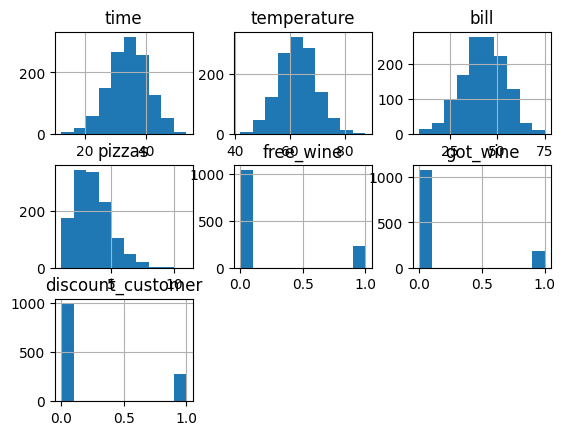

In [11]:
df.hist()

((array([-3.26497962, -3.00483933, -2.85999063, ...,  2.85999063,
          3.00483933,  3.26497962]),
  array([12.27, 13.28, 13.68, ..., 52.23, 52.32, 53.1 ])),
 (6.468174544010952, 34.22944707740916, 0.9991704046714602))

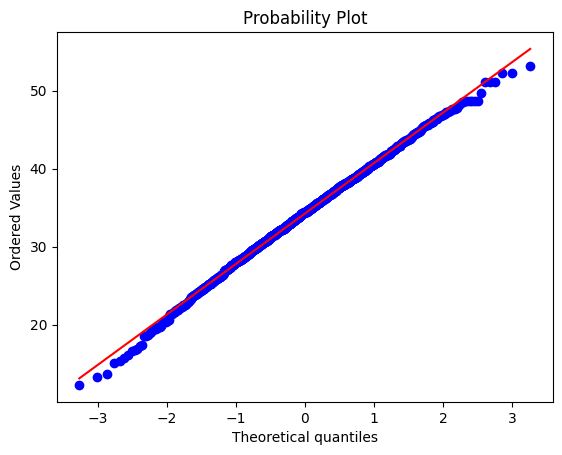

In [12]:
stats.probplot(df.time, dist='norm', plot=plt)

In [14]:
stats.probplot(df.time, dist='norm')[0]

(array([-3.26497962, -3.00483933, -2.85999063, ...,  2.85999063,
         3.00483933,  3.26497962]),
 array([12.27, 13.28, 13.68, ..., 52.23, 52.32, 53.1 ]))

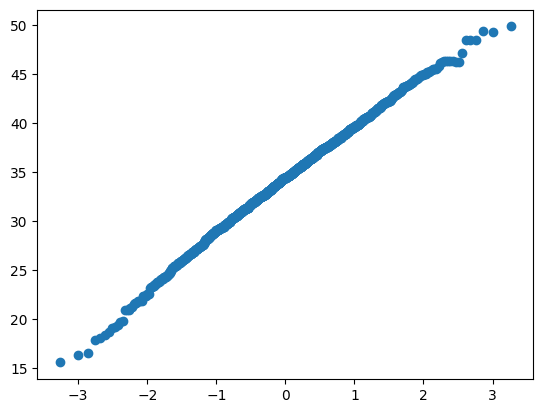

In [15]:
osm, osr = stats.probplot(df.time, dist='norm')[0]
residual = osr - osm
plt.scatter(osm, residual)

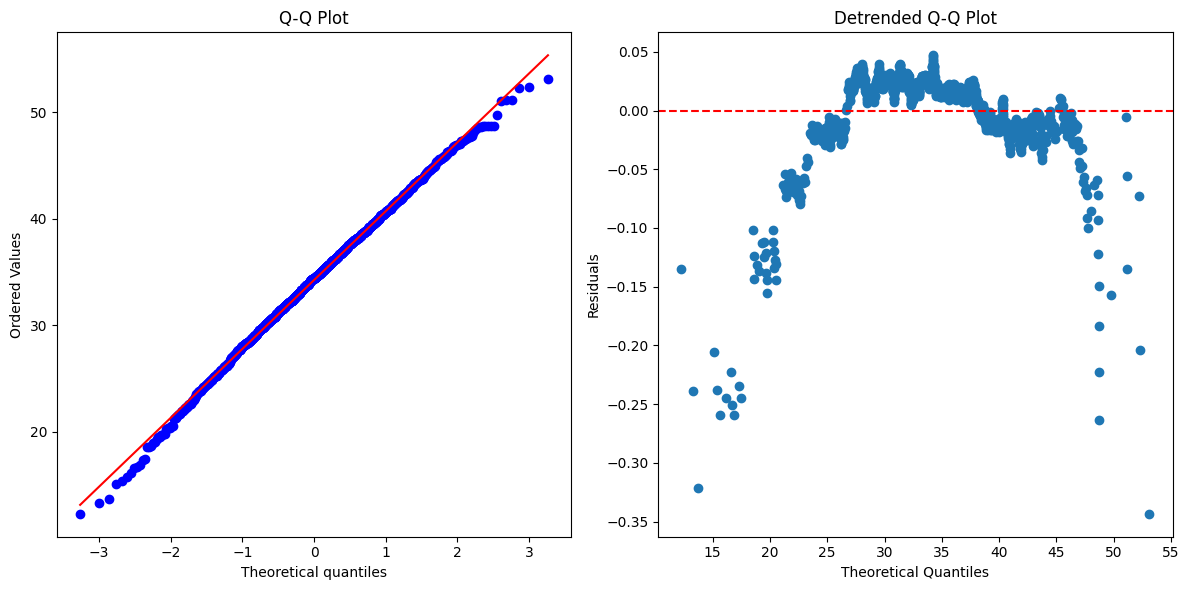

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Generate some data
np.random.seed(0)
data = df.time

# Q-Q plot
plt.figure(figsize=(12, 6))

# Subplot 1: Q-Q plot
plt.subplot(1, 2, 1)
stats.probplot(data, dist="norm", plot=plt)
plt.title('Q-Q Plot')

# Subplot 2: Detrended Q-Q plot
plt.subplot(1, 2, 2)
osm, osr = stats.probplot(data, dist="norm")[0]


# since our comparision is from standardized normal distributation quantiles
# we so also need to standardize our data point
resid = (osr - osr.mean()) / osr.std() - osm
plt.scatter(osr ,resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Detrended Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()


In [25]:
osm 

array([-3.26497962, -3.00483933, -2.85999063, ...,  2.85999063,
        3.00483933,  3.26497962])

array([ True,  True,  True, ...,  True,  True,  True])

In [36]:
emp_probabilities =  np.round(np.arange(1, len(osm)+1) - 0.5,2) / len(osm)

In [38]:
p_osm =  stats.norm.ppf(emp_probabilities)

In [41]:
p_osm

array([-3.35631362, -3.03950556, -2.8821715 , ...,  2.8821715 ,
        3.03950556,  3.35631362])

In [40]:
osr

array([12.27, 13.28, 13.68, ..., 52.23, 52.32, 53.1 ])

array([-0.13488358, -0.238651  , -0.32156985, ..., -0.07306174,
       -0.20397622, -0.3433533 ])